# TechMentor-LLM Dataset Report

Exploratory report for the unified instruction-tuning dataset.

In [1]:
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path("..").resolve()
RAW_DIR = ROOT / "data" / "raw"
CLEANED_PATH = ROOT / "data" / "cleaned" / "cleaned_dataset.json"
STATS_PATH = ROOT / "reports" / "dataset_stats.json"
TRAIN_PATH = ROOT / "data" / "processed" / "train.jsonl"
EVAL_PATH = ROOT / "data" / "processed" / "eval.jsonl"

## Dataset Size

In [2]:
with STATS_PATH.open(encoding="utf-8") as handle:
    stats = json.load(handle)

with CLEANED_PATH.open(encoding="utf-8") as handle:
    cleaned = json.load(handle)

size_df = pd.DataFrame(
    [
        {"Metric": "Raw Samples", "Count": stats["raw_records"]},
        {"Metric": "Clean Samples", "Count": stats["total_records"]},
        {"Metric": "Removed Samples", "Count": stats["removed_records"]},
    ]
)
size_df

,Metric,Count
0,Raw Samples,24242
1,Clean Samples,7928
2,Removed Samples,16314


## Category Distribution

In [3]:
df = pd.DataFrame(cleaned)
category_counts = df["category"].fillna("unknown").value_counts()

focus_categories = ["backend", "python", "sql", "ml", "system_design"]
category_summary = pd.DataFrame(
    {
        "Category": focus_categories,
        "Count": [int((df["category"] == cat).sum()) for cat in focus_categories],
    }
)
category_summary

,Category,Count
0,backend,7
1,python,7692
2,sql,13
3,ml,6
4,system_design,24


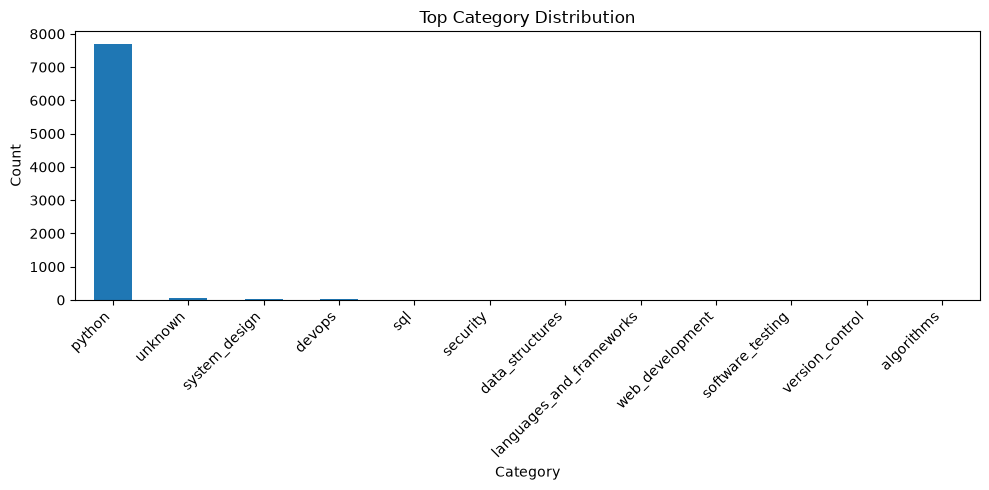

In [4]:
plt.figure(figsize=(10, 5))
category_counts.head(12).plot(kind="bar")
plt.title("Top Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Difficulty Distribution

In [5]:
difficulty_counts = df["difficulty"].fillna("unknown").value_counts()
difficulty_df = pd.DataFrame(
    {
        "Difficulty": ["easy", "medium", "hard", "unknown"],
        "Count": [
            int((df["difficulty"] == "easy").sum()),
            int((df["difficulty"] == "medium").sum()),
            int((df["difficulty"] == "hard").sum()),
            int(df["difficulty"].isna().sum()),
        ],
    }
)
difficulty_df

,Difficulty,Count
0,easy,6
1,medium,92
2,hard,76
3,unknown,7754


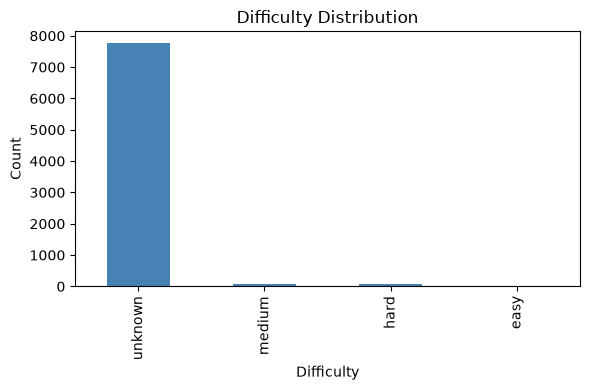

In [6]:
plt.figure(figsize=(6, 4))
difficulty_counts.plot(kind="bar", color="steelblue")
plt.title("Difficulty Distribution")
plt.xlabel("Difficulty")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Answer Length Statistics

In [7]:
answer_lengths = (
    df["answer"]
    .dropna()
    .astype(str)
    .str.split()
    .str.len()
)

length_stats = pd.DataFrame(
    [
        {"Metric": "Average", "Words": round(answer_lengths.mean(), 2)},
        {"Metric": "Median", "Words": float(answer_lengths.median())},
        {"Metric": "Maximum", "Words": int(answer_lengths.max())},
        {"Metric": "Minimum", "Words": int(answer_lengths.min())},
    ]
)
length_stats

,Metric,Words
0,Average,8.66
1,Median,7.00
2,Maximum,43.00
3,Minimum,5.00


## Duplicate Removal Statistics

In [8]:
duplicate_df = pd.DataFrame(
    [
        {"Metric": "Duplicates Removed", "Count": stats["duplicates_removed"]},
        {"Metric": "Remaining Records", "Count": stats["total_records"]},
    ]
)
duplicate_df

,Metric,Count
0,Duplicates Removed,16314
1,Remaining Records,7928


## Alpaca Split Summary

In [9]:
def load_jsonl(path: Path) -> list[dict]:
    rows = []
    with path.open(encoding="utf-8") as handle:
        for line in handle:
            rows.append(json.loads(line))
    return rows

train_rows = load_jsonl(TRAIN_PATH)
eval_rows = load_jsonl(EVAL_PATH)

alpaca_df = pd.DataFrame(
    [
        {"Split": "Train", "Count": len(train_rows)},
        {"Split": "Eval", "Count": len(eval_rows)},
        {"Split": "Total", "Count": len(train_rows) + len(eval_rows)},
    ]
)
alpaca_df

,Split,Count
0,Train,504
1,Eval,56
2,Total,560


## Sample Records

In [10]:
rng = random.Random(42)
samples = rng.sample(cleaned, k=min(10, len(cleaned)))
pd.DataFrame(samples)

,question,answer,candidate_answer,followup,code,category,difficulty,source
0,For what purpose does private method traverse ...,to find key and return the value stored,None,None,"def _find_value(ret_dict, key, path=None): if ...",python,NaN,codeqa
1,What do glyph have ?,a unicode value -- used by fdk to make otfs,None,None,"def setUnicodeValue(glyph, glyphList): if (gly...",python,NaN,codeqa
2,What is regression testing?,Regression testing ensures new code changes do...,None,None,NaN,software_testing,easy,kaggle
3,What loads an aff4 object ?,from a serialized yaml representation,None,None,def YamlLoader(string): representation = yaml....,python,NaN,codeqa
4,How does all validation function work to ensur...,as expected to combine validators,None,None,def test_all(): assert (not hug.validate.all(h...,python,NaN,codeqa
5,What is using dinitz algorithm ?,a maximum single - commodity flow,None,None,"def dinitz(G, s, t, capacity='capacity', resid...",python,NaN,codeqa
6,What creates in text ?,lazy imports for all of the imports,None,None,"def lazy_import(scope, text, lazy_import_class...",python,NaN,codeqa
7,What be added in the filter file ?,the list of filters and sources,None,None,def _AppendFiltersForMSBuild(parent_filter_nam...,python,NaN,codeqa
8,How is the tkinter package excluded by pil pac...,by frozen applications explicitly importing both,None,None,@importorskip('PIL') @importorskip(modname_tki...,python,NaN,codeqa
9,For what purpose do the xml message create to ...,to update the grade for a single graded assign...,None,None,"def send_score_update(assignment, score): xml ...",python,NaN,codeqa
